Минимальное число деревьев, при котором R² > 0.52: 21


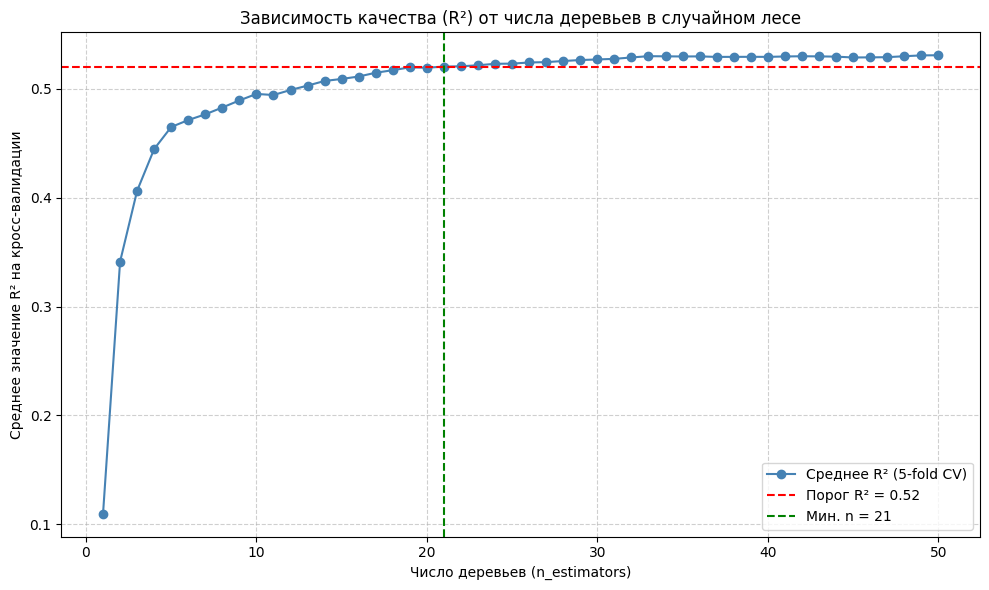

In [4]:
# Импорты
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

# 1. Загрузка и предобработка данных
df = pd.read_csv('data/abalone.csv')

# Преобразуем Sex: F → -1, I → 0, M → 1
df['Sex'] = df['Sex'].map({'F': -1, 'I': 0, 'M': 1})

# Признаки и целевая переменная
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# 2. Настройка кросс-валидации
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# 3. Перебор числа деревьев и вычисление R²
n_trees_range = list(range(1, 51))
r2_scores = []
min_n_for_threshold = None

for n in n_trees_range:
    model = RandomForestRegressor(n_estimators=n, random_state=1)
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    mean_r2 = np.mean(scores)
    r2_scores.append(mean_r2)
    
    if min_n_for_threshold is None and mean_r2 > 0.52:
        min_n_for_threshold = n

# 4. Вывод результата
print(f"Минимальное число деревьев, при котором R² > 0.52: {min_n_for_threshold}")

# 5. Построение графика
plt.figure(figsize=(10, 6))
plt.plot(n_trees_range, r2_scores, marker='o', linestyle='-', color='steelblue', label='Среднее R² (5-fold CV)')
plt.axhline(0.52, color='red', linestyle='--', linewidth=1.5, label='Порог R² = 0.52')

if min_n_for_threshold is not None:
    plt.axvline(min_n_for_threshold, color='green', linestyle='--', linewidth=1.5,
                label=f'Мин. n = {min_n_for_threshold}')

plt.title('Зависимость качества (R²) от числа деревьев в случайном лесе')
plt.xlabel('Число деревьев (n_estimators)')
plt.ylabel('Среднее значение R² на кросс-валидации')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()